Inspired by the great OpenAI Eval [Cookbooks](https://cookbook.openai.com/) by [Josiah Grace(OpenAI)](https://www.linkedin.com/in/josiahbgrace/)

# Evaluations Example: Choosing a Model-Prompt Combination for an LLM Router

Evals are task-oriented and iterative, they're the best way to check how your LLM integration is doing and improve it.

In the following eval, we are going to focus on the task of picking the model-prompt combination that provides the best performance, quality, and cost for our use-case.

Our use-case is:

1. We've created an [LLM-based Router](https://open.substack.com/pub/johndamask/p/using-llm-structured-outputs-for?r=2ee1b&utm_campaign=post&utm_medium=web&showWelcomeOnShare=true) for our budget chatbot. The router's job is to triage user requests and route them to the best component to meet the objective. Components can be other AI functions or native function calls that don't require AI.

2. We have a predetermined set of possible routes the model can choose from.

3. We have created a dataset of user inputs and the ideal response for comparison.

4. We want to see how detailed our prompt needs to be to achieve a high percentage of matches between the model output and the ideal response as labeled in our data file.

## Dataset:
Download [this example dataset](https://huggingface.co/datasets/jbdamask/llm-as-router-IT-budget-requests/resolve/main/llm-as-router-IT-budget-requests.jsonl) to your local computer.
Upload to OpenAI storage associated with your account:
1. Via [their website](https://platform.openai.com/storage/files/file-34G5t4Yhn6HiS2gKRHNjEw)
2. Via terminal
```
curl https://api.openai.com/v1/files \
  -H "Authorization: Bearer $OPENAI_API_KEY" \
  -F purpose="evals" \
  -F file="@llm-as-router-IT-budget-requests.jsonl"
```


### Set the dataset_file_id variable to the id provided by OpenAI.
For example (your file id will be different!)

In [ ]:
dataset_file_id = "file-F5vpTawCEy1MSj6bymt9hF"

In [ ]:
!pip install openai pydantic

In [ ]:
import os
import openai
from openai.types.chat import ChatCompletion
# import pydantic
from pydantic import BaseModel, Field
import os
import json
from enum import Enum


## Create OpenAI Client
This notebook was built in Google Colab and assumes the API key is in a stored secret.

In [ ]:
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

## Data Structure
The imported data is in JSON format:
`{"item":{"input":"Save it!","ideal":"download_file"}}`

We create a class to make it easy to handle the data.
(Note that "item" seems to be an internal key used by OpenAI Evals so we don't need to include it in our Class.)

This structure lets us reference record data like so, `{{item.ideal}}`

In [ ]:
class Record(BaseModel):
      input: str
      ideal: str

print(Record.model_json_schema()) # This function is used later when we configure our data_source_config

{'properties': {'input': {'title': 'Input', 'type': 'string'}, 'ideal': {'title': 'Ideal', 'type': 'string'}}, 'required': ['input', 'ideal'], 'title': 'Record', 'type': 'object'}


## Short Tangent: Chat Completions Example

This is a simple chat completions example. It's not related to the eval but demonstrates how the model responds when asked to be a router.


In [ ]:


DEVELOPER_PROMPT = """
You are a router.
Your only job is to determine which route best matches the user's query.
Your choices are:
- chat_response
- structured_response
- download_file
"""

tasks = []
def choose_route(input: str) -> str:
      result = openai.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "developer", "content": DEVELOPER_PROMPT},
            {"role": "user", "content": input},
        ]
      )
      return result.choices[0].message.content.strip()

r = {"input": "Create a budget item for 10 Mac M1s. They cost $3500 each.", "ideal": "structured_response"}
r2 = {"input": "I need 10 Mac M1s.", "ideal": "chat_response"}

example1 = Record(**r)
example2 = Record(**r2)

result1 = choose_route(example1.input)
print("Example 1:\nIdeal response: ", example1.ideal, "\nModel response: ", result1, "\nIs match? ", result1 == example1.ideal)

result2 = choose_route(example2.input)
print("\n\nExample 2:\nIdeal response: ", example2.ideal, "\nModel response: ", result2, "\nIs match? ", result2 == example2.ideal)

Example 1:
Ideal response:  structured_response 
Model response:  structured_response 
Is match?  True


Example 2:
Ideal response:  chat_response 
Model response:  structured_response 
Is match?  False


## Setting up your eval
An Eval holds the configuration that is shared across multiple Runs, it has two components:

1. Data source configuration `data_source_config` - the schema (columns) that your future Runs conform to.
  * Our data_source_config uses the `Record.model_json_schema()` function to define what variables are available in the Eval.
2. Testing Criteria `testing_criteria` - How you'll determine if your integration is working for each record.

In [ ]:
# This data_source_config defines what variables are available throughout the eval.
data_source_config = {
    "type": "custom", # We set this to custom because we're providing our own item_schema
    "item_schema": Record.model_json_schema(), # This lets our code access Record properties
    "include_sample_schema": True, # Necessary to access LLM response
}

In [ ]:
# This is our testing_criteria. It tells the Eval engine check if input==reference
router_grader = {
    "name": "Router Grader",
    "type": "string_check",             # Must be valid string that maps to an Eval type
    "input": "{{sample.output_text}}",  # LLM response to our query
    "reference": "{{item.ideal}}",      # Expected response from our dataset
    "operation": "eq"                   # Operations: eq, ne, like, ilike
}

Complete list of Eval types:
- custom
- label_model
- logs
- message
- output_text
- python
- score_model
- stored_completions
- string_check
- text_similarity

## Create Eval
Creating an Eval means registering it on OpenAI's platform. It acts as a template so you can run it many times with different datasets, duplicate it, etc.

We create it here and store the result so we can reference the Eval's ID later on.

In [ ]:
eval_create_result = openai.evals.create(
    name="Route check Eval",
    metadata={
        "description": "This eval tests several prompts and models to find the best performing combination.",
    },
    data_source_config=data_source_config,
    testing_criteria=[router_grader],
)
eval_id = eval_create_result.id
print(eval_id)

eval_681236d4fb3881909d2d340cfe87f9bd


## Create Prompts of Increasing Specificity
We start with a generic prompt and build on it.

Note that this is known as the Developer Prompt. See [OpenAI's docs](https://platform.openai.com/docs/guides/text?api-mode=chat#message-roles-and-instruction-following) for info on the different prompt roles.

In [ ]:
PROMPT_PREFIX = """
You are a router.
Your only job is to determine which route best matches the user's query.
"""

PROMPT_VARIATION_BASIC = f"""
{PROMPT_PREFIX}
Your choices are:
- chat_response
- structured_response
- download_file

You should return just the route and nothing else.

# Instructions
- Always review the entire user input message before responding
- You will choose the appropriate type of response based on your text_format instructions.
This will contain a set of structured outputs.
- You will always respond with text from the structured output set
- You will always return only one structured output
- If you unsure about what type to choose for response, you will respond with 'chat_response'.
- If the user asks for multiple things at once, you will go with respond with 'chat_response' unless it's clear
that the user wants to add multiple budget items, in which case you will returned 'structured_response'.
- You will only return 'download_file' if a reasaonable person would think that this is what the user is requesting.
"""

PROMPT_VARIATION_WITH_SAMPLES = f"""
{PROMPT_VARIATION_BASIC}

# Sample phrases
## Choose chat_response response if phrases like this appear anywhere in the user message
"Look up the price"
"Find me the latest..."
"Help me with ..."
"What are some options for ..."

## Choose structured_response
"Add a line item for ..."
"Add a budget item for ..."
"Add budget items for a, b, and c"
"Ok, let's go with the Enterprise option"

## Choose download_file
"Save it"
"Download this"
"Export my budget"

## Handling ambiguity
Note that certain queries may imply multiple routes. In such cases,
choose the route that best fits the main intent of the query.
If you cannot reasonably determine user intent, return 'chat_response'.
If the user asks for information that requires a search, this will take precedence over all other parts of the
user message and you will return 'chat_response'
"""

PROMPT_VARIATION_WITH_EXAMPLES = f"""
{PROMPT_VARIATION_WITH_SAMPLES}

# Examples
## Example 1
### User
Create a budget item for a LinkedIn Recruiter licenses. I need 20. Please look up the price.

### Assistant
chat_response

## Example 2
### User
Create a budget item for a one-time purchase of 10 MacBook M1 laptops with 16GB memory
and 1TB SSD for $30,000 to equip staff for biotech research and operations.

### Assistant
structured_response

## Example 3
### User
Great. Save it!

### Assistant
download_file

"""


prompts = [
    ("prefix_only", PROMPT_PREFIX),
    ("basic", PROMPT_VARIATION_BASIC),
    ("with_samples", PROMPT_VARIATION_WITH_SAMPLES),
    ("with_examples", PROMPT_VARIATION_WITH_EXAMPLES),
]

## Models
This is where we define the list of models to try. For a complete list of models run,

```
curl https://api.openai.com/v1/models \
  -H "Authorization: Bearer $OPENAI_API_KEY" | jq '.data[].id' | sort
```

In [ ]:
models = ["gpt-4o-mini", "gpt-4.1-mini", "gpt-4.1-nano"]

## Creating Runs
Our Eval, prompts, and models are set so now we can create Runs. To do this, we make a nested loop so every prompt is tested against every model.

The `input_messages` template shows where we're passing in the `prompt` as a parameter and we're also passing in the `{{item.input}}` from data set.

You may notice that we're not looping over our dataset in the code. This is because the eval engine does that for us. As long as we tell eval how to access the data (done here via the `file_id`), we're good to go.

In [ ]:
from openai import AsyncOpenAI
import asyncio
client = AsyncOpenAI()

# reports = []
tasks = []
for prompt_name, prompt in prompts:
    for model in models:
        run_data_source = {
            "type": "completions",
            "input_messages": {
                "type": "template",
                "template": [
                    {
                        "role": "developer",
                        "content": prompt,
                    },
                    {
                        "role": "user",
                        "content": "{{item.input}}",
                    },
                ],
            },
            "model": model,
            "source": {
                "type": "file_id",
                "id": dataset_file_id
            }
            # ,            "metadata": {"prompt": prompt_name}
        }

        # run_create_result = openai.evals.runs.create(
        tasks.append(client.evals.runs.create(
            eval_id=eval_id,
            name=f"{prompt_name}_{model}",
            data_source=run_data_source,
        ))

        # reports.append(run_create_result)
        # print(f"Report URL {model}, {prompt_name}:", run_create_result.report_url)

result = await asyncio.gather(*tasks)
# reports = []
for run in result:
    print(f"Report URL {run.report_url}")

Report URL https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd?project_id=proj_bQJXqx2gysr9UOe75tpUdFiD&run_id=evalrun_68123ce3790481908983664b091a62a7
Report URL https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd?project_id=proj_bQJXqx2gysr9UOe75tpUdFiD&run_id=evalrun_68123ce3b978819092dc79fc713e4dc2
Report URL https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd?project_id=proj_bQJXqx2gysr9UOe75tpUdFiD&run_id=evalrun_68123ce366d08190befebf9fa2b67a77
Report URL https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd?project_id=proj_bQJXqx2gysr9UOe75tpUdFiD&run_id=evalrun_68123ce3720081909ff943fa27aecafa
Report URL https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd?project_id=proj_bQJXqx2gysr9UOe75tpUdFiD&run_id=evalrun_68123ce60b5881909e849ac5e0351d12
Report URL https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd?project_id=proj_bQJXq

## View Results

Wait a few seconds to a minute to run this as your evals need to complete.

The chart below shows the results. Links are provided for each run to drill down into the data.

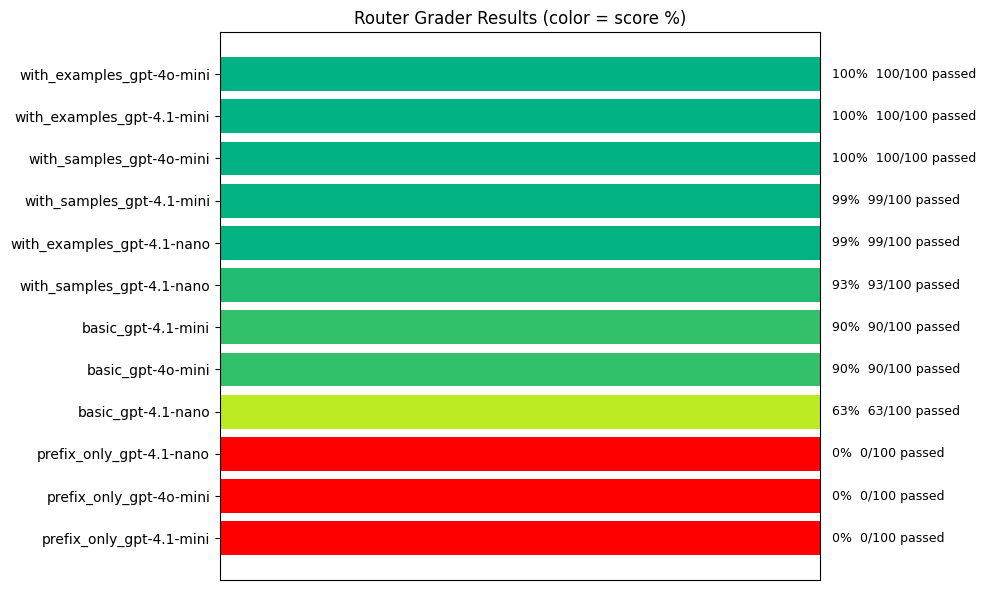

[with_examples_gpt-4o-mini](https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd/data?run_id=evalrun_68123ce3723881908ff813a91ccf2904) — 100%  (100/100 passed)

[with_examples_gpt-4.1-mini](https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd/data?run_id=evalrun_68123ce37e9c81909a693294098a55ef) — 100%  (100/100 passed)

[with_samples_gpt-4o-mini](https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd/data?run_id=evalrun_68123ce36ea48190a27fb593399246cb) — 100%  (100/100 passed)

[with_samples_gpt-4.1-mini](https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd/data?run_id=evalrun_68123ce37084819091bbd5bbbdb62847) — 99%  (99/100 passed)

[with_examples_gpt-4.1-nano](https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd/data?run_id=evalrun_68123ce3a26481909d0d39c1d1a9a53e) — 99%  (99/100 passed)

...

[basic_gpt-4o-mini](https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd/data?run_id=evalrun_68123ce3720081909ff943fa27aecafa) — 90%  (90/100 passed)

[basic_gpt-4.1-nano](https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd/data?run_id=evalrun_68123ce3765c8190818e533aced0df03) — 63%  (63/100 passed)

[prefix_only_gpt-4.1-nano](https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd/data?run_id=evalrun_68123ce366d08190befebf9fa2b67a77) — 0%  (0/100 passed)

[prefix_only_gpt-4o-mini](https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd/data?run_id=evalrun_68123ce3790481908983664b091a62a7) — 0%  (0/100 passed)

[prefix_only_gpt-4.1-mini](https://platform.openai.com/evaluations/eval_681236d4fb3881909d2d340cfe87f9bd/data?run_id=evalrun_68123ce3b978819092dc79fc713e4dc2) — 0%  (0/100 passed)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display, Markdown

# ── 1. Gather run results ──────────────────────────────────────────────────────
rows = []
# for report in reports:
for report in result:
    run = openai.evals.runs.retrieve(eval_id=report.eval_id,
                                     run_id=report.id)
    c = run.result_counts
    rows.append({
        "eval_id" : report.eval_id,
        "run_id"  : report.id,
        "name"    : run.name,
        "passed"  : c.passed,
        "failed"  : c.failed,
        "errored" : c.errored,
        "total"   : c.total,
    })

df = pd.DataFrame(rows)

# Compute score %
df["score_pct"] = df["passed"] / df["total"]

# Sort by score descending
df = df.sort_values("score_pct", ascending=False)

# Palette: red (0 %) -> yellow (~0.5) -> green (100 %)
palette = ["#ff0000", "#ffff00", "#00b284"]
cmap = mcolors.LinearSegmentedColormap.from_list("score_cmap", palette)
colors = [cmap(pct) for pct in df["score_pct"]]

# ── 2. Plot horizontal bars ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
bars = plt.barh(df["name"], [1]*len(df), color=colors)
plt.xlim(0, 1)
plt.xticks([])
plt.title("Router Grader Results (color = score %)")

# Annotate with score % and counts
for bar, pct, passed, total in zip(bars, df["score_pct"], df["passed"], df["total"]):
    plt.text(1.02, bar.get_y() + bar.get_height()/2,
             f"{int(pct*100)}%  {passed}/{total} passed",
             va="center", fontsize=9)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ── 3. Display clickable links below ────────────────────────────────────────────
for _, row in df.iterrows():
    url = f"https://platform.openai.com/evaluations/{row['eval_id']}/data?run_id={row['run_id']}"
    display(Markdown(f"[{row['name']}]({url}) — {int(row['score_pct'] * 100)}%  ({row['passed']}/{row['total']} passed)"))


## Congratulations!
The results of this eval allows you to make a data-driven decision about the best prompt to use and the most cost-effective model.

Try it with your own prompts and data.